In [ ]:
import pandas as pd
df = pd.read_csv('df_final.csv')
df.head()

In [ ]:
import pandas as pd

# 1. 미국 주(State)를 4대 지역(Region)으로 매핑 (미국 인구조사국 기준)
state_to_region = {
    # 동북부 (Northeast)
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    # 중서부 (Midwest)
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    # 남부 (South)
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    # 서부 (West)
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

# 가맹점 위치(MERCHANT_STATE) 기준으로 REGION 칼럼 추가
df['REGION'] = df['MERCHANT_STATE'].map(state_to_region).fillna('Unknown')

# 2. 지역별 & 온/오프라인별 결제 건수 기준 Top 5 가맹점 추출 함수
def get_regional_top_merchants(data):
    # 가맹점명과 카테고리를 함께 그룹화하여 건수와 금액 집계
    agg_df = data.groupby(['REGION', 'CARD_PRESENT_INDICATOR', 'MERCHANT_NAME', 'MERCHANT_CATEGORY_LEVEL_3']).agg(
        TX_COUNT=('TRANSACTION_ID', 'count'),
        TOTAL_SPEND=('GROSS_TRANSACTION_AMOUNT', 'sum')
    ).reset_index()
    
    # 건수(TX_COUNT) 기준으로 랭킹 부여
    agg_df['RANK'] = agg_df.groupby(['REGION', 'CARD_PRESENT_INDICATOR'])['TX_COUNT'].rank(method='first', ascending=False)
    
    # Top 5만 추출 (주 정보가 없는 Unknown 지역 제외)
    top_5 = agg_df[(agg_df['RANK'] <= 5) & (agg_df['REGION'] != 'Unknown')]
    
    return top_5.sort_values(by=['REGION', 'CARD_PRESENT_INDICATOR', 'RANK'])

# 3. 결과 도출 및 출력
regional_insights = get_regional_top_merchants(df)

print("📍 [지역별 & 온/오프라인별] 결제 건수 Top 5 가맹점")
display(regional_insights)

📍 [지역별 & 온/오프라인별] 결제 건수 Top 5 가맹점


,REGION,CARD_PRESENT_INDICATOR,MERCHANT_NAME,MERCHANT_CATEGORY_LEVEL_3,TX_COUNT,TOTAL_SPEND,RANK
97,Midwest,Card Not Present,MCDONALDS,QSR Burgers,44102,463124.52,1.0
167,Midwest,Card Not Present,TACO BELL,Mexican Restaurants,10750,171409.87,2.0
47,Midwest,Card Not Present,DOMINOS,Pizza Restaurants,9357,275129.91,3.0
50,Midwest,Card Not Present,DUNKIN DONUTS,Breakfast Restaurants,7151,60814.39,4.0
29,Midwest,Card Not Present,CHICK-FIL-A,QSR Chicken,6728,124976.47,5.0
365,Midwest,Card Present,MCDONALDS,QSR Burgers,194939,2205214.67,1.0
194,Midwest,Card Present,365 RETAIL MARKETS,Vending & Beverage Retailers,137573,576253.70,2.0
396,Midwest,Card Present,NO ENTITY,Vending & Beverage Retailers,59385,211911.63,3.0
465,Midwest,Card Present,TACO BELL,Mexican Restaurants,53853,802724.94,4.0
495,Midwest,Card Present,WENDYS,QSR Burgers,44319,601729.45,5.0


In [ ]:
mask = regional_insights['CARD_PRESENT_INDICATOR'].isin(['Card Present', 'Card Not Present'])
filtered_df = regional_insights[mask]
filtered_df

,REGION,CARD_PRESENT_INDICATOR,MERCHANT_NAME,MERCHANT_CATEGORY_LEVEL_3,TX_COUNT,TOTAL_SPEND,RANK
97,Midwest,Card Not Present,MCDONALDS,QSR Burgers,44102,463124.52,1.0
167,Midwest,Card Not Present,TACO BELL,Mexican Restaurants,10750,171409.87,2.0
47,Midwest,Card Not Present,DOMINOS,Pizza Restaurants,9357,275129.91,3.0
50,Midwest,Card Not Present,DUNKIN DONUTS,Breakfast Restaurants,7151,60814.39,4.0
29,Midwest,Card Not Present,CHICK-FIL-A,QSR Chicken,6728,124976.47,5.0
365,Midwest,Card Present,MCDONALDS,QSR Burgers,194939,2205214.67,1.0
194,Midwest,Card Present,365 RETAIL MARKETS,Vending & Beverage Retailers,137573,576253.70,2.0
396,Midwest,Card Present,NO ENTITY,Vending & Beverage Retailers,59385,211911.63,3.0
465,Midwest,Card Present,TACO BELL,Mexican Restaurants,53853,802724.94,4.0
495,Midwest,Card Present,WENDYS,QSR Burgers,44319,601729.45,5.0


■ 군집별 지역 분포 건수
REGION            Midwest  Northeast   South  Unknown    West
CLUSTER_NAME                                                 
0. 장기 유령           152720      52439  221992     9891  146490
1. 소액/다빈도(Gen Z)   560470     121688  616543    66626  295658
2. 고단가 VIP         406390      87935  454580    78956  267674
3. 신규 급감(체리피커)     318630      83520  425989    47706  223223 

■ 군집 내 지역 비중 (%)
REGION            Midwest  Northeast  South  Unknown  West
CLUSTER_NAME                                              
0. 장기 유령             26.2        9.0   38.0      1.7  25.1
1. 소액/다빈도(Gen Z)     33.7        7.3   37.1      4.0  17.8
2. 고단가 VIP           31.4        6.8   35.1      6.1  20.7
3. 신규 급감(체리피커)       29.0        7.6   38.8      4.3  20.3 



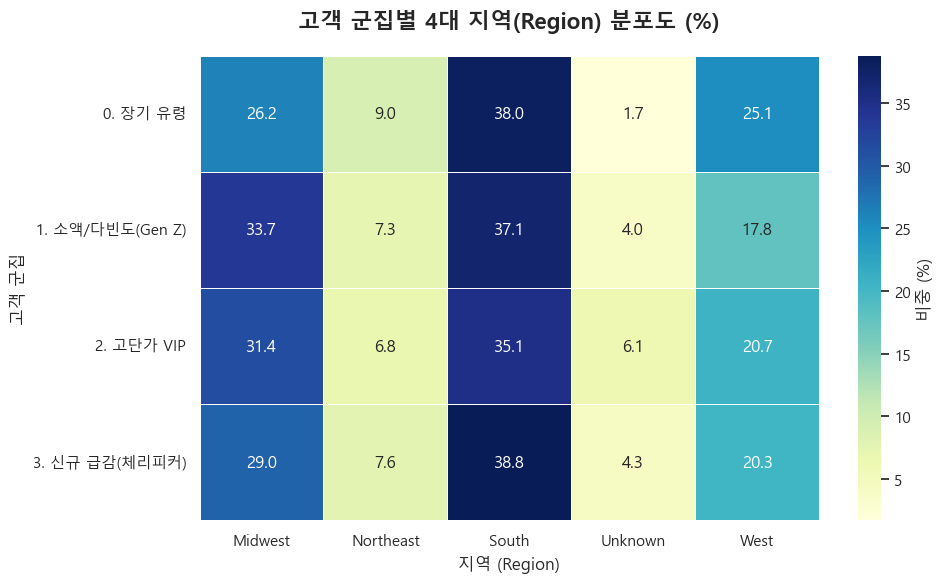

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- [사전 설정] 한글 폰트 및 마이너스 기호 깨짐 방지 ---
sns.set_theme(style="whitegrid")
plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

# 군집 이름 매핑 (직관적인 출력을 위해)
cluster_mapping = {
    0: '0. 장기 유령', 
    1: '1. 소액/다빈도(Gen Z)', 
    2: '2. 고단가 VIP', 
    3: '3. 신규 급감(체리피커)'
}
df['CLUSTER_NAME'] = df['CLUSTER_K4'].map(cluster_mapping)

# ---------------------------------------------------------
# 1. 데이터 추출: 군집 vs 지역 교차표 (Cross-tab)
# ---------------------------------------------------------
# 절대 건수 기준
region_count = pd.crosstab(df['CLUSTER_NAME'], df['REGION'])

# 군집 내 지역 비중 (%) 기준 (가로 합이 100%가 되도록 정규화)
region_ratio = pd.crosstab(df['CLUSTER_NAME'], df['REGION'], normalize='index') * 100

print("■ 군집별 지역 분포 건수")
print(region_count, "\n")
print("■ 군집 내 지역 비중 (%)")
print(region_ratio.round(1), "\n")


# ---------------------------------------------------------
# 2. 시각화: 군집별 지역 분포 히트맵 (Heatmap)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# 비중(%) 데이터를 바탕으로 히트맵 생성 (색상이 진할수록 비중이 높음)
sns.heatmap(
    region_ratio, 
    annot=True,          # 셀 안에 숫자 표시
    fmt=".1f",           # 소수점 1자리까지
    cmap="YlGnBu",       # 시각적으로 편안한 Yellow-Green-Blue 컬러맵
    cbar_kws={'label': '비중 (%)'},
    linewidths=.5,
    ax=ax
)

plt.title('고객 군집별 4대 지역(Region) 분포도 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지역 (Region)', fontsize=12)
plt.ylabel('고객 군집', fontsize=12)

# Y축 라벨 가로로 똑바로 읽히게 회전
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

■ 특정 지역 내 고객 군집 구성비 (%) - 세로 합 100%
REGION        Midwest  Northeast  South  Unknown  West
CLUSTER_NAME                                          
0. 장기 유령         10.6       15.2   12.9      4.9  15.7
1. 소액/다빈도        39.0       35.2   35.9     32.8  31.7
2. 고단가 VIP       28.3       25.4   26.4     38.9  28.7
3. 신규 급감         22.2       24.2   24.8     23.5  23.9 



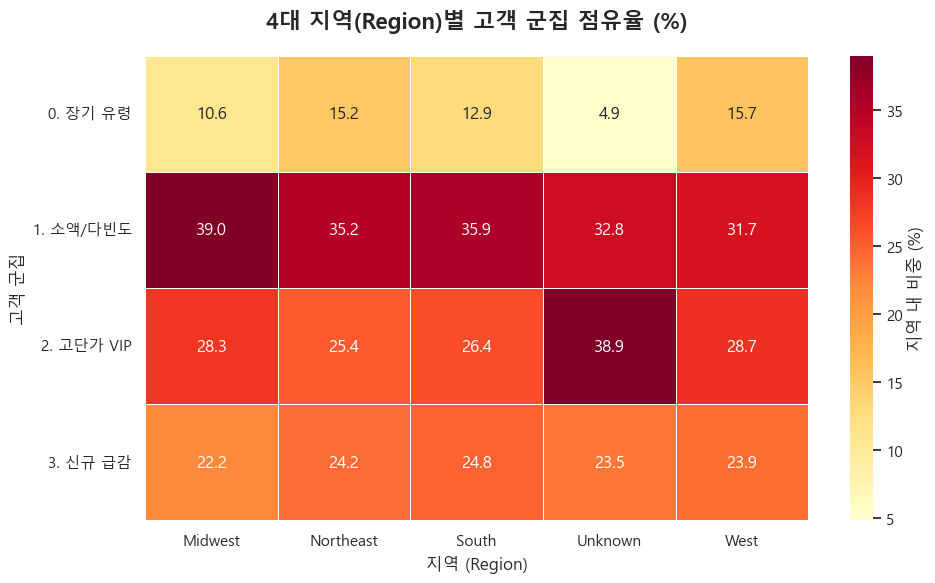

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- [사전 설정] 한글 폰트 및 테마 설정 ---
sns.set_theme(style="whitegrid")
plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 데이터 집계: 지역(Region)을 100%로 둔 군집 비중 계산
# ---------------------------------------------------------
# normalize='columns'를 사용하여 각 세로축(지역)의 합이 100%가 되도록 합니다.
region_col_ratio = pd.crosstab(df['CLUSTER_NAME'], df['REGION'], normalize='columns') * 100

print("■ 특정 지역 내 고객 군집 구성비 (%) - 세로 합 100%")
print(region_col_ratio.round(1), "\n")


# ---------------------------------------------------------
# 2. 시각화: 지역 기준 군집 분포 히트맵
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# 이전 차트(파란색/초록색)와 헷갈리지 않도록 붉은/오렌지색 톤(YlOrRd) 사용
sns.heatmap(
    region_col_ratio, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': '지역 내 비중 (%)'},
    linewidths=.5,
    ax=ax
)

plt.title('4대 지역(Region)별 고객 군집 점유율 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지역 (Region)', fontsize=12)
plt.ylabel('고객 군집', fontsize=12)

# Y축 라벨 가로로 똑바로 읽히게 회전
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

■ 군집 내 세대별 구성비 (%)
CARD_HOLDER_GENERATION  Baby Boomer  Gen X  Gen Z  Millennial  Silent
CLUSTER_NAME                                                         
0. 장기 유령                       17.9   34.1    9.5        38.2     0.3
1. 소액/다빈도                      15.3   21.0   25.4        37.7     0.5
2. 고단가 VIP                     13.8   32.2   11.4        42.2     0.4
3. 신규 급감                       19.1   28.5   14.0        37.8     0.6 



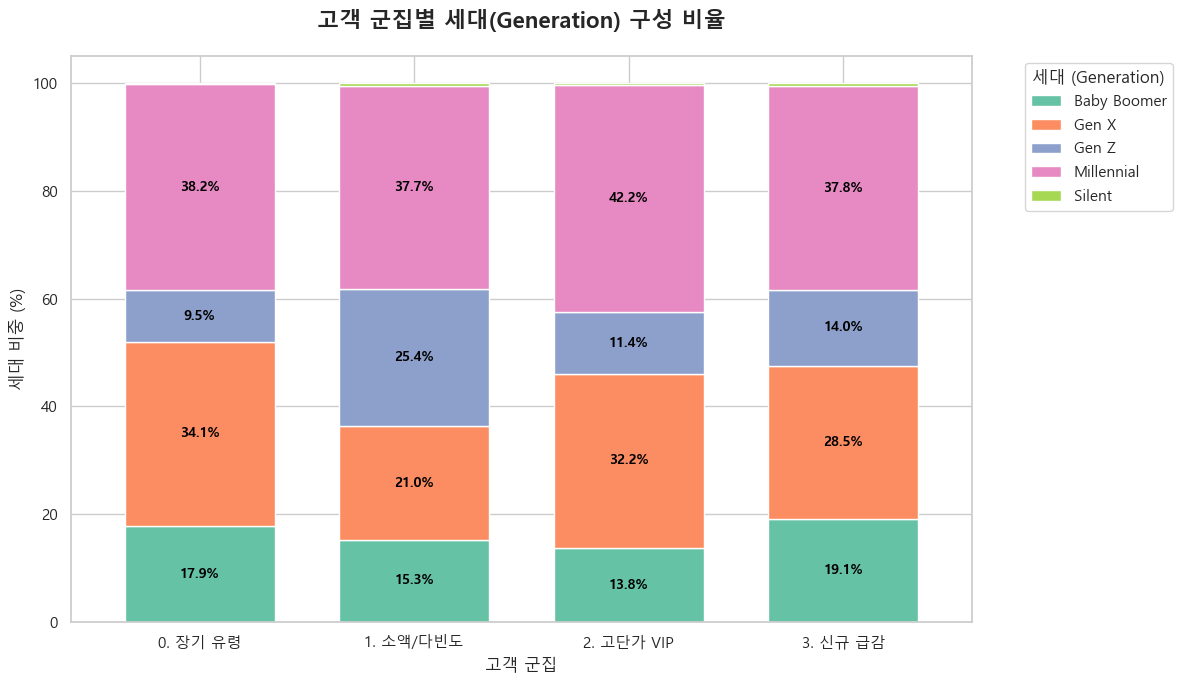

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- [사전 설정] 한글 폰트 및 테마 설정 ---
sns.set_theme(style="whitegrid")
plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

# 군집 이름 매핑
cluster_mapping = {
    0: '0. 장기 유령', 
    1: '1. 소액/다빈도', 
    2: '2. 고단가 VIP', 
    3: '3. 신규 급감'
}
df['CLUSTER_NAME'] = df['CLUSTER_K4'].map(cluster_mapping)

# ---------------------------------------------------------
# 1. 데이터 집계: 군집별 세대(Generation) 비중 (%) 계산
# ---------------------------------------------------------
# groupby를 사용해 교차표(Cross-tab) 형태로 변환
generation_pivot = df.groupby(['CLUSTER_NAME', 'CARD_HOLDER_GENERATION'])['ACCOUNT_ID'].nunique().unstack(fill_value=0)

# 각 군집별 100% 비율로 정규화 (가로 합 100%)
generation_ratio = generation_pivot.div(generation_pivot.sum(axis=1), axis=0) * 100

print("■ 군집 내 세대별 구성비 (%)")
print(generation_ratio.round(1), "\n")


# ---------------------------------------------------------
# 2. 시각화: 100% 누적 막대그래프 (Stacked Bar)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

# 세대별 색상 지정 (세대가 4~5개일 경우를 대비해 Seaborn 팔레트 사용)
colors = sns.color_palette("Set2", n_colors=len(generation_ratio.columns))

# 누적 막대그래프 그리기
generation_ratio.plot(
    kind='bar', 
    stacked=True, 
    color=colors, 
    width=0.7, 
    ax=ax
)

plt.title('고객 군집별 세대(Generation) 구성 비율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('고객 군집', fontsize=12)
plt.ylabel('세대 비중 (%)', fontsize=12)
plt.xticks(rotation=0)

# 범례 위치 조정 (그래프 밖 우측 상단)
plt.legend(title='세대 (Generation)', bbox_to_anchor=(1.05, 1), loc='upper left')

# 막대 중앙에 퍼센트(%) 텍스트 삽입
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    # 높이가 3% 이상인 구역에만 텍스트 표시 (너무 좁은 구역 텍스트 겹침 방지)
    if height > 3:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

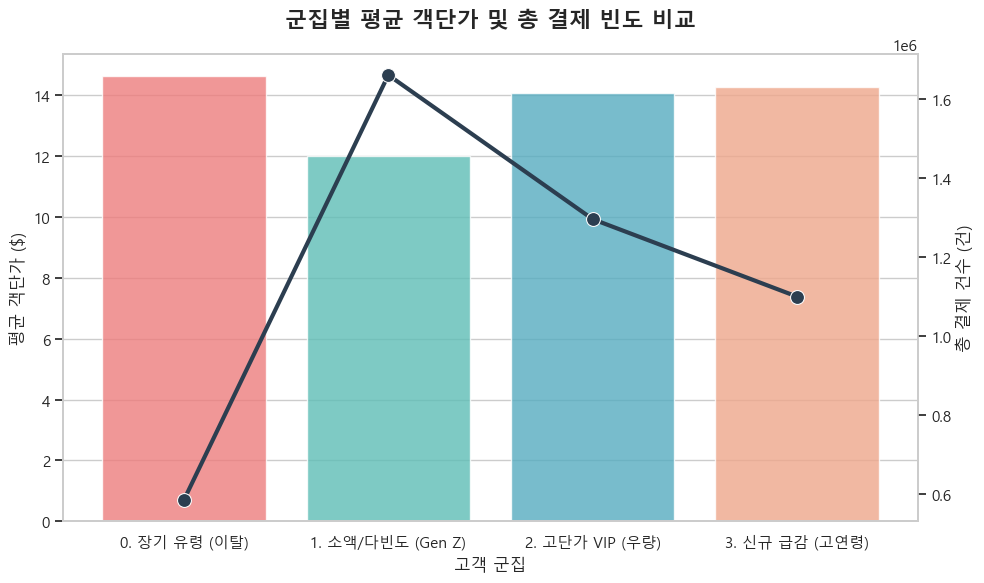

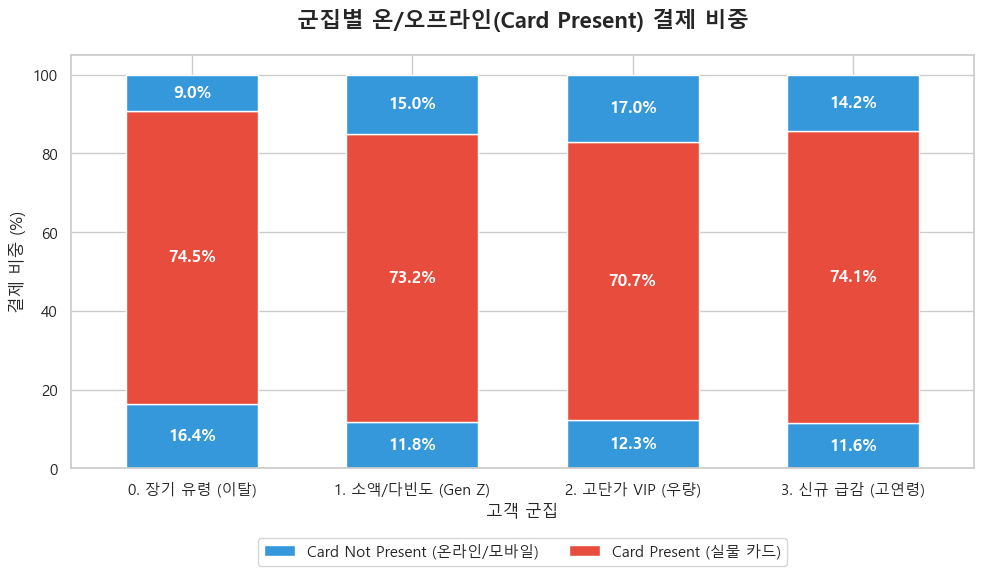

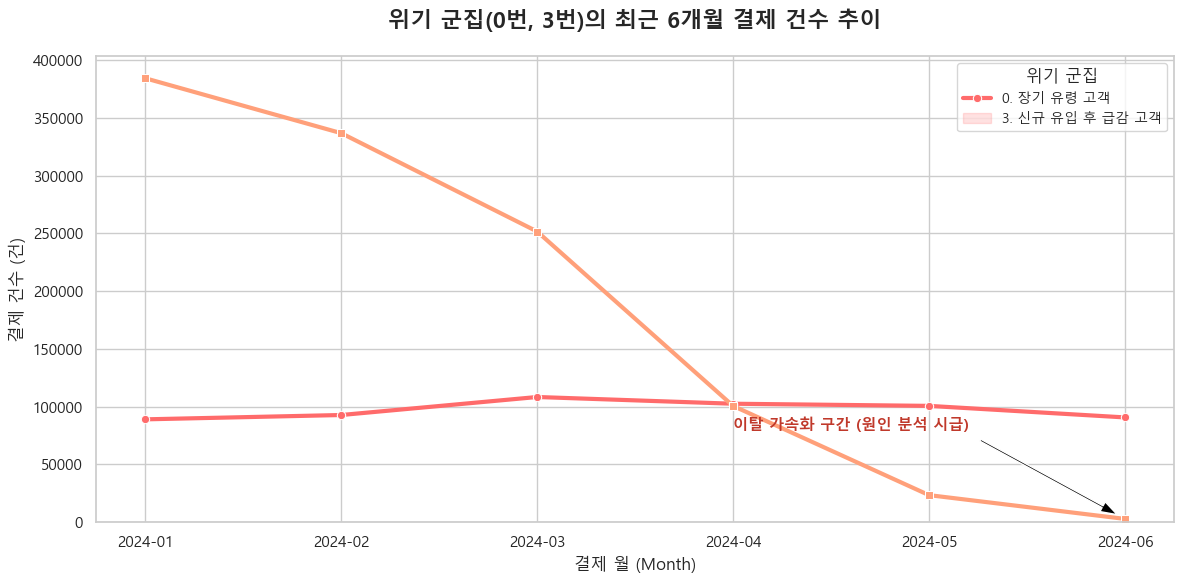

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- [사전 설정] 경영진 보고용 깔끔한 테마 및 한글 폰트 설정 ---
sns.set_theme(style="whitegrid")
# Windows 사용 시: 
plt.rc('font', family='Malgun Gothic')
# Mac 사용 시: plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 군집 직관성을 위한 이름 매핑
cluster_names = {
    0: '0. 장기 유령 (이탈)', 
    1: '1. 소액/다빈도 (Gen Z)', 
    2: '2. 고단가 VIP (우량)', 
    3: '3. 신규 급감 (고연령)'
}
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']


# ---------------------------------------------------------
# 차트 1. 군집별 체급 비교 (객단가 vs 결제빈도)
# 목적: 1번(다빈도)과 2번(고단가)의 타겟팅 전략이 완전히 달라야 함을 시각적 대비로 증명
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# X축: 군집, Y축1(막대): 객단가
sns.barplot(
    data=cluster_summary.reset_index(), 
    x='CLUSTER_K4', y='Avg_Txn_Amount', 
    palette=cluster_colors, ax=ax1, alpha=0.8
)
ax1.set_title('군집별 평균 객단가 및 총 결제 빈도 비교', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('고객 군집', fontsize=12)
ax1.set_ylabel('평균 객단가 ($)', fontsize=12)
ax1.set_xticklabels([cluster_names[i] for i in range(4)])

# Y축2(꺾은선): 총 결제 빈도
ax2 = ax1.twinx()
sns.lineplot(
    data=cluster_summary.reset_index(), 
    x='CLUSTER_K4', y='Total_Txn_Count', 
    color='#2C3E50', marker='o', markersize=10, linewidth=3, ax=ax2
)
ax2.set_ylabel('총 결제 건수 (건)', fontsize=12)
ax2.grid(False) # 축이 겹쳐 지저분해지는 것을 방지

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 차트 2. 온/오프라인 결제 비중 (100% Stacked Bar)
# 목적: 1번 군집의 모바일 친화성과 3번 군집의 오프라인 고립 현상 한눈에 보기
# ---------------------------------------------------------
# channel_ratio 데이터프레임 사용 (index: 군집, columns: Card Present / Not Present)
ax = channel_ratio.plot(
    kind='bar', stacked=True, figsize=(10, 6), 
    color=['#3498DB', '#E74C3C'], width=0.6
)

plt.title('군집별 온/오프라인(Card Present) 결제 비중', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('고객 군집', fontsize=12)
plt.ylabel('결제 비중 (%)', fontsize=12)
plt.xticks(ticks=range(4), labels=[cluster_names[i] for i in range(4)], rotation=0)
plt.legend(['Card Not Present (온라인/모바일)', 'Card Present (실물 카드)'], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# 막대 중앙에 % 텍스트 삽입
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # 5% 이상인 구간에만 텍스트 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 차트 3. 위기 군집(0번, 3번)의 월별 결제량 추락 트렌드
# 목적: 이탈이 서서히 일어났는지, 특정 달에 급락했는지 경영진에게 경고
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# monthly_trend 데이터프레임 사용 (index: YYYY-MM, columns: 군집)
# 0번(장기유령)과 3번(신규이탈)만 필터링하여 시각화
risk_clusters = monthly_trend[[0, 3]]
risk_clusters.index = risk_clusters.index.astype(str) # X축 출력을 위해 문자열 변환

sns.lineplot(data=risk_clusters, markers=['o', 's'], dashes=False, linewidth=3, palette=['#FF6B6B', '#FFA07A'])

plt.title('위기 군집(0번, 3번)의 최근 6개월 결제 건수 추이', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 월 (Month)', fontsize=12)
plt.ylabel('결제 건수 (건)', fontsize=12)
plt.legend(['0. 장기 유령 고객', '3. 신규 유입 후 급감 고객'], title='위기 군집', fontsize=10)

# Y축 시작을 0으로 설정하여 하락폭을 왜곡 없이 보여줌
plt.ylim(bottom=0) 

# 급락 포인트를 강조하는 주석 (예시: 마지막 달 데이터 기준)
last_month_val = risk_clusters.iloc[-1][3]
plt.annotate('이탈 가속화 구간 (원인 분석 시급)', 
             xy=(len(risk_clusters)-1, last_month_val), 
             xytext=(len(risk_clusters)-3, last_month_val + (risk_clusters.max().max()*0.2)),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.show()

■ 1. 4대 지역별 전체 주말 결제 비중 (%)
REGION
West         27.4
Northeast    26.9
South        26.6
Unknown      26.3
Midwest      24.8
Name: IS_WEEKEND, dtype: float64 

■ 2. 지역 및 군집별 주말 결제 비중 교차표 (%)
CLUSTER_NAME  0. 장기 유령  1. 소액/다빈도  2. 고단가 VIP  3. 신규 급감
REGION                                                 
Midwest           24.5       24.6        25.1      25.0
Northeast         26.4       26.7        27.3      27.0
South             26.8       26.2        26.9      26.6
Unknown           29.1       25.9        26.5      26.1
West              27.3       27.0        27.8      27.6 



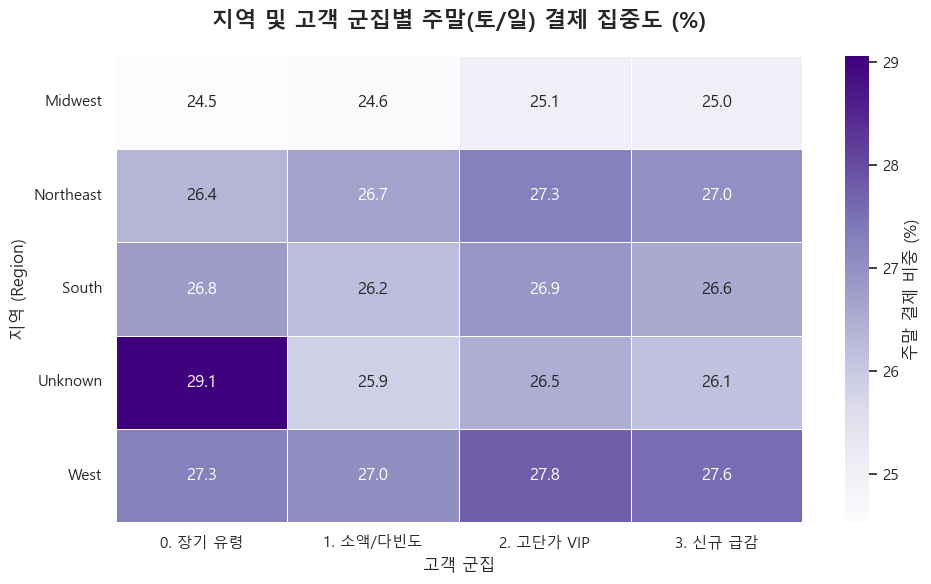

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- [사전 설정] 한글 폰트 및 테마 설정 ---
sns.set_theme(style="whitegrid")
plt.rc('font', family='Malgun Gothic') # Windows 환경
# plt.rc('font', family='AppleGothic') # Mac 환경
plt.rcParams['axes.unicode_minus'] = False

# 군집 이름 매핑 (안 되어 있을 경우를 대비)
cluster_mapping = {
    0: '0. 장기 유령', 
    1: '1. 소액/다빈도', 
    2: '2. 고단가 VIP', 
    3: '3. 신규 급감'
}
if 'CLUSTER_NAME' not in df.columns:
    df['CLUSTER_NAME'] = df['CLUSTER_K4'].map(cluster_mapping)

# ---------------------------------------------------------
# 1. 요일 및 주말 파생 변수 생성
# ---------------------------------------------------------
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
# dt.dayofweek: 0(월요일) ~ 6(일요일)
df['DAY_OF_WEEK'] = df['TRANSACTION_DATE'].dt.dayofweek 
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5, 6]) # 5:토, 6:일

# ---------------------------------------------------------
# 2. 데이터 집계: 지역별 / 군집별 주말 결제 비중 (%)
# ---------------------------------------------------------
# 지역 전체의 주말 비중 비교
weekend_ratio_region = df.groupby('REGION')['IS_WEEKEND'].mean() * 100

print("■ 1. 4대 지역별 전체 주말 결제 비중 (%)")
print(weekend_ratio_region.round(1).sort_values(ascending=False), "\n")

# 지역(행) x 군집(열) 주말 비중 교차표
weekend_pivot = df.pivot_table(
    index='REGION',
    columns='CLUSTER_NAME',
    values='IS_WEEKEND',
    aggfunc='mean'
) * 100

print("■ 2. 지역 및 군집별 주말 결제 비중 교차표 (%)")
print(weekend_pivot.round(1), "\n")

# ---------------------------------------------------------
# 3. 시각화: 주말 결제 집중도 히트맵
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# 보라색 톤(Purples)을 사용하여 주말 집중도가 높을수록 진하게 표시
sns.heatmap(
    weekend_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="Purples", 
    cbar_kws={'label': '주말 결제 비중 (%)'},
    linewidths=.5,
    ax=ax
)

plt.title('지역 및 고객 군집별 주말(토/일) 결제 집중도 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('고객 군집', fontsize=12)
plt.ylabel('지역 (Region)', fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

오프라인 편중 고객 수: 2,635,872명 / 거래 건수: 3,231,467건
온라인 편중 고객 수: 896,111명 / 거래 건수: 1,109,551건


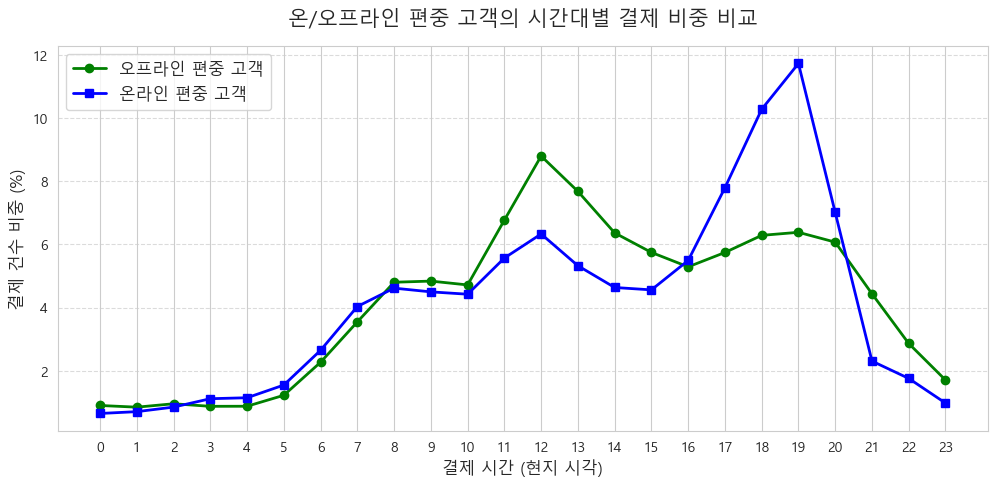


🛒 [오프라인 편중 고객] 결제 금액 Top 10 업종


,소비 업종 (Lv.3),총 결제 금액,비중(%),그룹
65,QSR Burgers,"12,352,389",34.6%,오프라인 편중
66,QSR Chicken,"5,248,601",14.7%,오프라인 편중
54,Mexican Restaurants,"4,000,364",11.2%,오프라인 편중
21,Coffee / Tea,"3,375,194",9.5%,오프라인 편중
68,QSR Sandwiches,"3,005,592",8.4%,오프라인 편중
1,American Restaurants,"2,738,358",7.7%,오프라인 편중
80,Vending & Beverage Retailers,"1,430,772",4.0%,오프라인 편중
15,Breakfast Restaurants,"1,195,320",3.4%,오프라인 편중
64,Pizza Restaurants,"1,165,375",3.3%,오프라인 편중
38,Food Services,"1,144,690",3.2%,오프라인 편중



💻 [온라인 편중 고객] 결제 금액 Top 10 업종


,소비 업종 (Lv.3),총 결제 금액,비중(%),그룹
55,QSR Burgers,"3,385,847",23.2%,온라인 편중
54,Pizza Restaurants,"2,585,867",17.7%,온라인 편중
20,Coffee / Tea,"2,412,061",16.5%,온라인 편중
56,QSR Chicken,"1,985,884",13.6%,온라인 편중
47,Mexican Restaurants,"1,365,047",9.4%,온라인 편중
58,QSR Sandwiches,"1,191,589",8.2%,온라인 편중
71,Vending & Beverage Retailers,"488,319",3.3%,온라인 편중
15,Breakfast Restaurants,"465,200",3.2%,온라인 편중
1,American Restaurants,"436,500",3.0%,온라인 편중
36,General Retail,"261,177",1.8%,온라인 편중


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 폰트 설정 (맥 사용 시 'AppleGothic'으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 극단적 온/오프라인 타겟 고객 추출 (기준: 결제액 비중 80% 쏠림)
# ---------------------------------------------------------
# account_agg 데이터프레임이 메모리에 있다고 가정합니다.
offline_heavy_ids = account_agg[account_agg['OFFLINE_RATIO'] >= 0.8]['ACCOUNT_ID']
online_heavy_ids = account_agg[account_agg['OFFLINE_RATIO'] <= 0.2]['ACCOUNT_ID']

# 원본 df에서 해당 고객들의 거래 내역만 필터링
df_offline = df[df['ACCOUNT_ID'].isin(offline_heavy_ids)]
df_online = df[df['ACCOUNT_ID'].isin(online_heavy_ids)]

print(f"오프라인 편중 고객 수: {len(offline_heavy_ids):,}명 / 거래 건수: {len(df_offline):,}건")
print(f"온라인 편중 고객 수: {len(online_heavy_ids):,}명 / 거래 건수: {len(df_online):,}건")

# ---------------------------------------------------------
# 2. 소비 시간대(Hour) 비교 시각화
# ---------------------------------------------------------
# 각 그룹의 시간대별 '거래 횟수 비중(%)' 계산
offline_hour_pct = df_offline['Hour'].value_counts(normalize=True).sort_index() * 100
online_hour_pct = df_online['Hour'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(offline_hour_pct.index, offline_hour_pct.values, label='오프라인 편중 고객', color='green', marker='o', linewidth=2)
ax.plot(online_hour_pct.index, online_hour_pct.values, label='온라인 편중 고객', color='blue', marker='s', linewidth=2)

ax.set_title('온/오프라인 편중 고객의 시간대별 결제 비중 비교', fontsize=15, pad=15)
ax.set_xlabel('결제 시간 (현지 시각)', fontsize=12)
ax.set_ylabel('결제 건수 비중 (%)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.show()

# ---------------------------------------------------------
# 3. 소비 업종(Level 3) Top 10 비교 (결제 금액 기준)
# ---------------------------------------------------------
def get_top_categories(data, group_name):
    top_cat = data.groupby('MERCHANT_CATEGORY_LEVEL_3')['GROSS_TRANSACTION_AMOUNT'].sum().reset_index()
    top_cat = top_cat.sort_values(by='GROSS_TRANSACTION_AMOUNT', ascending=False).head(10)
    top_cat['비중(%)'] = (top_cat['GROSS_TRANSACTION_AMOUNT'] / top_cat['GROSS_TRANSACTION_AMOUNT'].sum()) * 100
    top_cat.columns = ['소비 업종 (Lv.3)', '총 결제 금액', '비중(%)']
    top_cat['그룹'] = group_name
    return top_cat

top_offline_cat = get_top_categories(df_offline, '오프라인 편중')
top_online_cat = get_top_categories(df_online, '온라인 편중')

print("\n🛒 [오프라인 편중 고객] 결제 금액 Top 10 업종")
display(top_offline_cat.style.format({'총 결제 금액': '{:,.0f}', '비중(%)': '{:.1f}%'}))

print("\n💻 [온라인 편중 고객] 결제 금액 Top 10 업종")
display(top_online_cat.style.format({'총 결제 금액': '{:,.0f}', '비중(%)': '{:.1f}%'}))